#Carga de Datos Limpios y Limpieza Predictiva

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion estetica
sns.set_theme(style='whitegrid')

# Cargamos el dataset de la Fase 1
df_ml = pd.read_csv('TelecomX_dataset_limpio.csv')

# Eliminamos customerID porque no aporta nada al patron matematico de abandono
df_ml = df_ml.drop('customerID', axis=1)

print("✅ Datos cargados y columna ID eliminada.")
print("Forma actual:", df_ml.shape)


✅ Datos cargados y columna ID eliminada.
Forma actual: (7267, 21)


#Codificación Categórica

In [22]:
# Transformamos magicamente todo lo que sea texto a variables binarias
# Usamos drop_first=True para evitar la multicolinealidad
df_encoded = pd.get_dummies(df_ml, drop_first=True)

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

print("✅ One-Hot Encoding Aplicado.")
print("Nuevas columnas generadas por las categorias:", df_encoded.shape[1])
df_encoded.head(3)


✅ One-Hot Encoding Aplicado.
Nuevas columnas generadas por las categorias: 32


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Monthly,Total,Cuentas_Diarias,...,TechSupport_yes,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0.0,0.0,1,1,9,1,1,65.6,593.30,2.16,...,1,0,1,0,0,1,0,0,0,1
1,0.0,0.0,0,0,9,1,0,59.9,542.40,1.97,...,0,0,0,0,1,0,0,0,0,1
2,1.0,0.0,0,0,4,1,1,73.9,280.85,2.43,...,0,0,0,0,0,0,0,0,1,0


#Diagnóstico de Desbalanceo de Clases

=== DISTRIBUCIÓN DE CHURN (Variable Objetivo) ===
Se quedaron (0): 5174 (73.46%)
Se fueron   (1): 1869 (26.54%)


/tmp/ipykernel_681/3003676838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_encoded, x='Churn', palette='viridis')


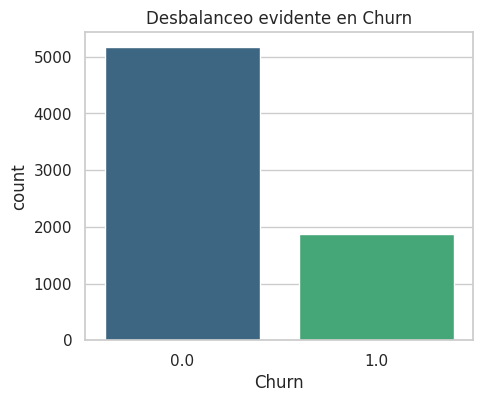

⚠️ ALERTA: Tenemos un desbalance grave. Si no hacemos SMOTE o Oversampling, el modelo se volverá vago y siempre predecirá 0.


In [23]:
# Analizando la proporcion de la variable objetivo
churn_counts = df_encoded['Churn'].value_counts()
churn_prop = df_encoded['Churn'].value_counts(normalize=True) * 100

print("=== DISTRIBUCIÓN DE CHURN (Variable Objetivo) ===")
print(f"Se quedaron (0): {churn_counts[0]} ({churn_prop[0]:.2f}%)")
print(f"Se fueron   (1): {churn_counts[1]} ({churn_prop[1]:.2f}%)")

# visual
plt.figure(figsize=(5,4))
sns.countplot(data=df_encoded, x='Churn', palette='viridis')
plt.title('Desbalanceo evidente en Churn')
plt.show()

# Insight automatico
if churn_prop[0] > 65:
    print("⚠️ ALERTA: Tenemos un desbalance grave. Si no hacemos SMOTE o Oversampling, el modelo se volverá vago y siempre predecirá 0.")


# Separación de Datos

In [24]:
from sklearn.model_selection import train_test_split

# Limpieza de ultima milla: Eliminamos cualquier fila donde Churn se haya colado como nulo (NaN)
if df_encoded['Churn'].isnull().sum() > 0:
    df_encoded = df_encoded.dropna(subset=['Churn'])

# X son las caracteristicas, y es lo que queremos predecir
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Separamos: 70% para estudiar (entrenar) y 30% para el examen (testear)
# stratify=y asegura que mantenga el mismo % de churn en test que en train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print("✅ Datos purgados de nulos y separados exitosamente (Split 70/30)")
print("Tamaño del entrenamiento:", X_train.shape)
print("Tamaño del test:", X_test.shape)

✅ Datos purgados de nulos y separados exitosamente (Split 70/30)
Tamaño del entrenamiento: (4930, 31)
Tamaño del test: (2113, 31)


#SMOTE

In [25]:
from imblearn.over_sampling import SMOTE

# Aplicamos SMOTE estrictamente en los datos de entrenamiento (hacerlo en el Test es considerado trampa).
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("⚖️ Clases balanceadas con exito (técnica SMOTE).")
print("Antes (vago):", y_train.value_counts().to_dict())
print("Despues (listo para aprender):", y_train_smote.value_counts().to_dict())


⚖️ Clases balanceadas con exito (técnica SMOTE).
Antes (vago): {0.0: 3622, 1.0: 1308}
Despues (listo para aprender): {0.0: 3622, 1.0: 3622}


#Estandarización de Escalas

In [26]:
from sklearn.preprocessing import StandardScaler

# Ajustamos las reglas de escala SOLO con los datos que tenemos permiso de ver (Train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)

# Al examen (Test) solo le aplicamos las mismas reglas, sin repasarlo
X_test_scaled = scaler.transform(X_test)

print("📏 Datos estandarizados correctamente (Media 0, Varianza 1).")


📏 Datos estandarizados correctamente (Media 0, Varianza 1).


#Entrenamiento de la IA

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- MODELO 1: Regresion Logistica (El clasico rey estadistico) ---
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train_smote)

# --- MODELO 2: Random Forest (Mucha fuerza bruta basada en arboles) ---
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_smote, y_train_smote)

print("🧠 Ambos modelos han entrenado exitosamente con la data sintetica del SMOTE.")


🧠 Ambos modelos han entrenado exitosamente con la data sintetica del SMOTE.


#Evaluación y Matrices de Confusión

📊 RESULTADOS: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

         0.0       0.87      0.80      0.84      1552
         1.0       0.55      0.67      0.60       561

    accuracy                           0.77      2113
   macro avg       0.71      0.74      0.72      2113
weighted avg       0.79      0.77      0.77      2113


🌳 RESULTADOS: RANDOM FOREST
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.85      1552
         1.0       0.59      0.61      0.60       561

    accuracy                           0.78      2113
   macro avg       0.72      0.73      0.72      2113
weighted avg       0.79      0.78      0.78      2113



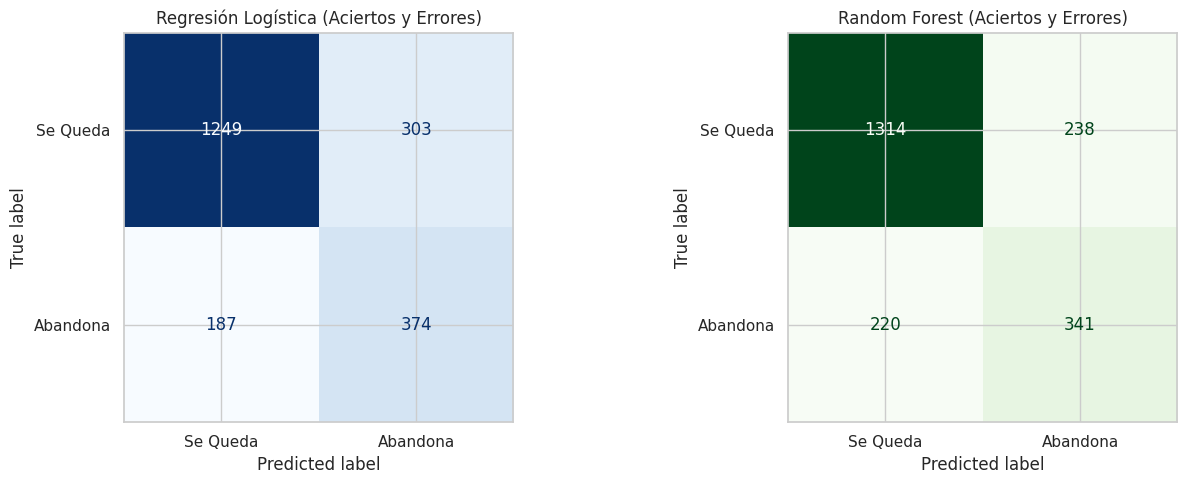

💡 INSIGHT: Fíjate en los Cuadrantes Inferiores Derechos de los gráficos (True Positives). El modelo que tenga el número más alto detectó exitosamente a más desertores.


In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Rinden el examen
predicciones_lr = modelo_lr.predict(X_test_scaled)
predicciones_rf = modelo_rf.predict(X_test)

print("="*45)
print("📊 RESULTADOS: REGRESIÓN LOGÍSTICA")
print("="*45)
print(classification_report(y_test, predicciones_lr))

print("\n" + "="*45)
print("🌳 RESULTADOS: RANDOM FOREST")
print("="*45)
print(classification_report(y_test, predicciones_rf))

# Y visualizamos sus cerebros graficando donde se equivocan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, predicciones_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Se Queda', 'Abandona']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Regresión Logística (Aciertos y Errores)')

cm_rf = confusion_matrix(y_test, predicciones_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Se Queda', 'Abandona']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest (Aciertos y Errores)')

plt.tight_layout()
plt.show()

print("💡 INSIGHT: Fíjate en los Cuadrantes Inferiores Derechos de los gráficos (True Positives). El modelo que tenga el número más alto detectó exitosamente a más desertores.")


#El Origen del Churn

/tmp/ipykernel_681/3187791426.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_evasion, x='Impacto_Matematico', y='Variable', ax=axes[0], palette='Reds_r')
/tmp/ipykernel_681/3187791426.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_retencion, x='Impacto_Matematico', y='Variable', ax=axes[1], palette='Greens_d')


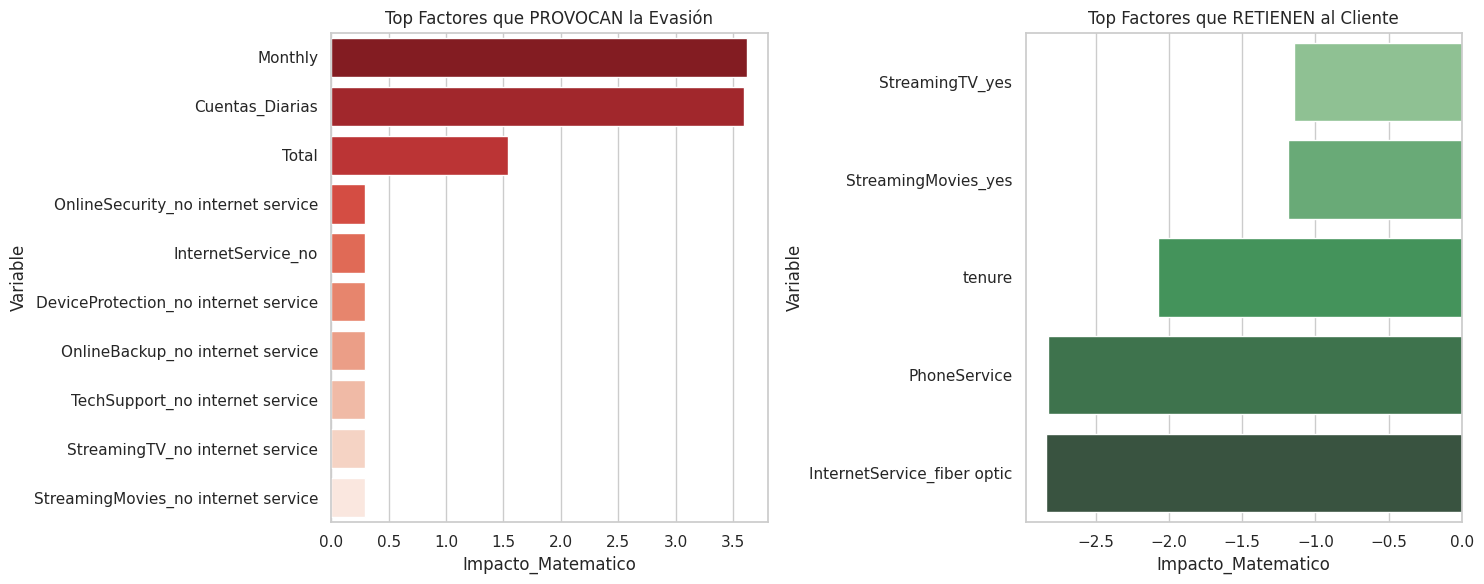

In [29]:
# Extraemos los coeficientes (pesos) que la Regresion Logistica le asignó a cada variable
coeficientes = modelo_lr.coef_[0]

# Los empatamos con los nombres de las columnas que estudió
importancia_features = pd.DataFrame({
    'Variable': X_train_smote.columns,
    'Impacto_Matematico': coeficientes
})

# Ordenamos del que mas empuja al abandono al que mas retiene
importancia_features = importancia_features.sort_values(by='Impacto_Matematico', ascending=False)

top_evasion = importancia_features.head(10)
top_retencion = importancia_features.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Culpables
sns.barplot(data=top_evasion, x='Impacto_Matematico', y='Variable', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top Factores que PROVOCAN la Evasión')

# Salvadores
sns.barplot(data=top_retencion, x='Impacto_Matematico', y='Variable', ax=axes[1], palette='Greens_d')
axes[1].set_title('Top Factores que RETIENEN al Cliente')

plt.tight_layout()
plt.show()
